# Tutorial: Transformers from Scratch on Tiny Shakespeare

Author: Helen Qu

## Overview

In this tutorial, you will build a **decoder-only transformer** (a small GPT-like language model) from scratch in PyTorch, train it on a public dataset, and use it to generate text.

### Learning goals
By the end you will:
1. Understand what self-attention computes (as a sequence-to-sequence mixing operator)
2. Implement a GPT-style Transformer block
3. Train a small autoregressive language model
4. Sample from the model to generate text

### What we will train on
We'll use **Tiny Shakespeare** (a single text file) and do **character-level language modeling**:
- Input: a window of characters (context)
- Target: the next character at each position


## 0. Dependencies

We use:
- `torch`
- `numpy`
- `matplotlib`
- `tqdm`
- `datasets` (Hugging Face) to fetch the text easily

If you're running locally:
```bash
pip install torch numpy matplotlib tqdm datasets
```

If running on Colab, make sure you're running on a GPU runtime (dropdown on top right hand corner -> "Change runtime type")! If you are, the next cell should print `device(type='cuda')`.

In [4]:
import math
import os
import time
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 1. Load Tiny Shakespeare

We'll pull the dataset, turn the raw text into integers (token IDs), then create training batches of (context, next-token targets).

In [5]:
import requests

url = 'https://raw.githubusercontent.com/karpathy/char-rnn/refs/heads/master/data/tinyshakespeare/input.txt'
response = requests.get(url)
response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
text = response.text

print('Num characters:', len(text))
print(text[:400])

Num characters: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 


### Character vocabulary
We build a vocabulary of unique characters.

- `stoi`: char → integer id
- `itos`: integer id → char

This is a minimal tokenizer: most modern LLMs use subword tokenizers like BPE, but the modeling mechanics are identical.

In [6]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s: str):
    return [stoi[c] for c in s]

def decode(ids):
    return ''.join([itos[i] for i in ids])

print('Vocab size:', vocab_size)
print('First 20 chars:', chars[:20])
print('Roundtrip test (expect "Hello!"):', decode(encode('Hello!')))

Vocab size: 65
First 20 chars: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Roundtrip test (expect "Hello!"): Hello!


### Train/val split

We'll use a simple split of the character stream:
- train: first 90%
- val: last 10%

We store the dataset as a single `torch.LongTensor` of token IDs.

In [7]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
train_data.shape, val_data.shape

(torch.Size([1003854]), torch.Size([111540]))

## 2. Build a language modeling dataset

For autoregressive LM:
- Input `x`: a length-`T` context window
- Target `y`: the same window shifted by 1 character

So the model learns to predict `x[t+1]` from `x[:t+1]`.

We sample random contiguous windows from the full stream.

In [8]:
@dataclass
class Config:
    block_size: int = 128   # context length
    batch_size: int = 64
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0.1
    lr: float = 3e-4
    weight_decay: float = 0.1
    max_steps: int = 2000
    eval_every: int = 200
    eval_steps: int = 50

cfg = Config()

class CharWindowDataset(Dataset):
    def __init__(self, token_stream: torch.Tensor, block_size: int):
        self.data = token_stream
        self.block_size = block_size

    def __len__(self):
        # each item uses block_size+1 tokens (because of the shifted target)
        return len(self.data) - (self.block_size + 1)

    def __getitem__(self, idx):
        chunk = self.data[idx : idx + self.block_size + 1]
        x = chunk[:-1]
        y = chunk[1:]
        return x, y

train_ds = CharWindowDataset(train_data, cfg.block_size)
val_ds = CharWindowDataset(val_data, cfg.block_size)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)

xb, yb = next(iter(train_loader))
print('x batch:', xb.shape, xb.dtype)
print('y batch:', yb.shape, yb.dtype)
print('Example decode x[0]:')
print(decode(xb[0].tolist()))

x batch: torch.Size([64, 128]) torch.int64
y batch: torch.Size([64, 128]) torch.int64
Example decode x[0]:
paring makes huge waste,
For beauty starved with her severity
Cuts beauty off from all posterity.
She is too fair, too wise, wis


## 3. Transformer building blocks

A GPT-style decoder-only Transformer repeats this pattern:

**(1) Tokenize + positional embeddings**

**(2) Repeated blocks** (LayerNorm → masked self-attention → residual; LayerNorm → MLP → residual)

**(3) Output head** that maps embedding vectors to logits over the vocabulary.

### Masked self-attention (causal)
Self-attention computes a *data-dependent mixing* of value vectors:
$$
A = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d}} + \text{mask}\right),\quad\mathrm{Attn}(X)=AV
$$
The causal mask enforces **no looking ahead**: token at position *t* may only attend to positions \(\le t\).

In [9]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head

        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

        # causal mask: [1, 1, T, T] for broadcasting over batch and heads
        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer('mask', mask)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)  # (B, T, 3C)
        q, k, v = qkv.split(C, dim=-1)

        # (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        # attention scores
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (B, nh, T, T)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)

        y = att @ v  # (B, nh, T, head_dim)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_drop(self.proj(y))
        return y


class MLP(nn.Module):
    def __init__(self, n_embd: int, dropout: float):
        super().__init__()
        self.fc1 = nn.Linear(n_embd, 4 * n_embd)
        self.fc2 = nn.Linear(4 * n_embd, n_embd)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Block(nn.Module):
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = MLP(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

## 4. The GPT-style model

Key components:
- token embedding: `wte`
- positional embedding: `wpe`
- stack of Transformer blocks
- final LayerNorm
- linear head to logits

We train with standard cross-entropy loss over next-token targets.


In [10]:
class GPT(nn.Module):
    def __init__(self, vocab_size: int, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.vocab_size = vocab_size

        self.wte = nn.Embedding(vocab_size, cfg.n_embd)
        self.wpe = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.drop = nn.Dropout(cfg.dropout)

        self.blocks = nn.ModuleList([
            Block(cfg.n_embd, cfg.n_head, cfg.block_size, cfg.dropout)
            for _ in range(cfg.n_layer)
        ])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.head = nn.Linear(cfg.n_embd, vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.cfg.block_size

        pos = torch.arange(0, T, device=idx.device)
        tok_emb = self.wte(idx)                  # (B, T, C)
        pos_emb = self.wpe(pos)[None, :, :]      # (1, T, C)
        x = self.drop(tok_emb + pos_emb)

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.head(x)                    # (B, T, vocab)

        loss = None
        if targets is not None:
            # flatten batch+time for cross entropy
            loss = F.cross_entropy(logits.view(-1, self.vocab_size), targets.view(-1))

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int, temperature: float = 1.0, top_k: int | None = None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.cfg.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is None:
                # No top_k, just apply temperature
                probs = F.softmax(logits, dim=-1)
            else:
                # Apply top_k sampling
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('inf')
                probs = F.softmax(logits, dim=-1)

            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx


model = GPT(vocab_size, cfg).to(device)
# Save the initial, untrained model state to a variable by explicitly cloning each tensor
untrained_state_dict = {k: v.clone() for k, v in model.state_dict().items()}

num_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nParameters: {num_params/1e6:.2f}M")

# sanity check
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)
logits, loss = model(x, y)
logits.shape, loss.item()

GPT(
  (wte): Embedding(65, 128)
  (wpe): Embedding(128, 128)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=128, out_features=384, bias=True)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (resid_drop): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=128, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=128, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=128, out_features=65, bias=False)
)

Parameters: 0.83M


(torch.Size([64, 128, 65]), 4.155352592468262)

## 5. Training loop

We train with AdamW (common for Transformers) and evaluate periodically.

### A note on metrics
For language modeling, a standard metric is **negative log-likelihood** (cross-entropy). You’ll also see **perplexity**:
$$
\mathrm{ppl} = \exp(\text{cross-entropy})
$$
Lower is better.


In [11]:
def estimate_loss(model, loader, eval_steps: int):
    model.eval()
    losses = []
    with torch.no_grad():
        it = iter(loader)
        for _ in range(eval_steps):
            x, y = next(it)
            x, y = x.to(device), y.to(device)
            _, loss = model(x, y)
            losses.append(loss.item())
    model.train()
    return float(np.mean(losses))


optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

train_losses = []
val_losses = []
steps = 0

t0 = time.time()
pbar = tqdm(total=cfg.max_steps)

train_iter = iter(train_loader)
while steps < cfg.max_steps:
    try:
        x, y = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        x, y = next(train_iter)

    x, y = x.to(device), y.to(device)

    logits, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    steps += 1
    pbar.update(1)

    if steps % cfg.eval_every == 0 or steps == 1:
        tr = estimate_loss(model, train_loader, cfg.eval_steps)
        va = estimate_loss(model, val_loader, cfg.eval_steps)
        train_losses.append((steps, tr))
        val_losses.append((steps, va))
        print(f"step {steps} | train {tr:.3f} | val {va:.3f} | ppl {math.exp(va):.1f}")

pbar.close()
print(f"Done in {(time.time()-t0):.1f}s")

train_losses[:3], val_losses[:3]

  0%|          | 0/2000 [00:00<?, ?it/s]

step 1 | train 3.880 | val 3.896 | ppl 49.2
step 200 | train 2.457 | val 2.458 | ppl 11.7
step 400 | train 2.289 | val 2.297 | ppl 9.9
step 600 | train 2.152 | val 2.181 | ppl 8.9
step 800 | train 1.996 | val 2.060 | ppl 7.8
step 1000 | train 1.876 | val 1.971 | ppl 7.2
step 1200 | train 1.793 | val 1.912 | ppl 6.8
step 1400 | train 1.720 | val 1.859 | ppl 6.4
step 1600 | train 1.653 | val 1.814 | ppl 6.1
step 1800 | train 1.616 | val 1.762 | ppl 5.8
step 2000 | train 1.572 | val 1.741 | ppl 5.7
Done in 69.7s


([(1, 3.8797356605529787),
  (200, 2.456587562561035),
  (400, 2.2892283391952515)],
 [(1, 3.8955296421051027), (200, 2.457821469306946), (400, 2.297001757621765)])

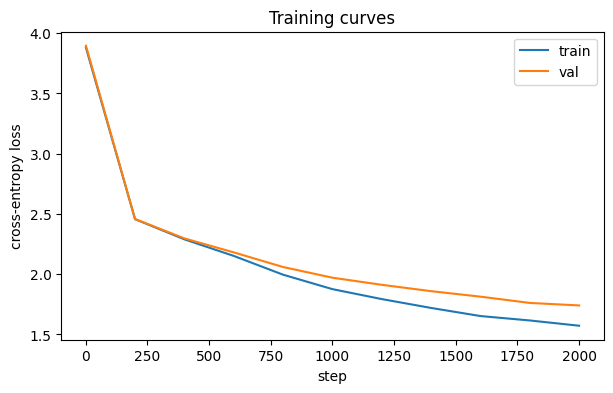

In [12]:
# Plot training curves
steps_tr, vals_tr = zip(*train_losses)
steps_va, vals_va = zip(*val_losses)

plt.figure(figsize=(7,4))
plt.plot(steps_tr, vals_tr, label='train')
plt.plot(steps_va, vals_va, label='val')
plt.xlabel('step')
plt.ylabel('cross-entropy loss')
plt.title('Training curves')
plt.legend()
plt.show()

## 6. Sampling / text generation

Generation is just repeated next-token sampling:
1. Feed context through model → logits
2. Convert logits → probabilities
3. Sample a token
4. Append token and repeat

We’ll seed with a short prompt and generate more characters.

**Tip:** `temperature` controls randomness (lower = more deterministic). `top_k` truncates to the most likely tokens.


In [13]:
prompt = "ROMEO: "
idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

# Generate with the trained model
print("--- Generated text (Trained Model) ---")
gen_trained = model.generate(idx, max_new_tokens=600, temperature=0.9, top_k=50)
print(decode(gen_trained[0].tolist()))

# Load the untrained model state from the variable and generate text
untrained_model = GPT(vocab_size, cfg).to(device)
untrained_model.load_state_dict(untrained_state_dict)

print("\n--- Generated text (Untrained Model) ---")
gen_untrained = untrained_model.generate(idx, max_new_tokens=600, temperature=0.9, top_k=50)
print(decode(gen_untrained[0].tolist()))

--- Generated text (Trained Model) ---
ROMEO: too your bids since.

QUEEN MONTARET:
Which me provopple that good enemian?
Are, proy you light and death, in one heaok; with thou
do the we provine plishain, thy lord.

LUCIO:
Thou'st that have the bay lord a hade, and my advied
I speak that a fair heer for slay show reving they aword,
Where should one husbost fathelly the nor petriaguey
And in fesch thones, and rogring stares me: death
look me stranges you stand's strishep in heart,
And off my man to make you many like of your lifet a
That they, they firse; but iWear'd thy varges, stand my good
To make may bre the hearts compisure, but O War

--- Generated text (Untrained Model) ---
ROMEO: yhVtQIzWplmuKDcL GUtVtDcqA:u!VgdqPFIGxE!.PLmn
szd$baqWDvq
zsEUww$oaepUqN.l?.tzeCuxivIQBUiVE&DdUmwR'SgRax3ULuq PS,szF$xoRnUGQiHshesIRZuLW$Ri?$Aav;.DRcaTSQlRZBEK?HVCygg.UdAu
hA:SHptSUvU!hZ;,CafepeamAw oA
VsZ!R.IW
WcxY?kk$SpMSaBeKCehP;3F&NzpygqlyDN?.&hMdncaWBe lJUtGKseC!fK?VLfkRspqAuEae.3qHAtEO-3h zeSla$lr

## 7. What did we actually build? (Concept recap)

### (A) The model is a conditional distribution
Autoregressive LM factorizes a joint distribution over sequences:
$$
p(x_1,\dots,x_T)=\prod_{t=1}^T p(x_t\mid x_{<t}).
$$
Training maximizes likelihood (minimizes NLL / cross-entropy).

### (B) Self-attention as a learned, data-dependent mixing operator
Given sequence embeddings $X\in\mathbb{R}^{T\times d}\$, attention computes weighted sums of value vectors, where weights depend on dot-products between queries and keys.

### (C) Causality is enforced by masking
Without the causal mask, the model could “cheat” by attending to future tokens.

### (D) Why does depth help?
Each block alternates:
- **mixing across time** (attention)
- **mixing across features** (MLP)

Stacking blocks composes these transformations into a powerful sequence model.
